In [5]:
import os
import time
from pathlib import Path

import whisper
import torch

from vosk import Model, KaldiRecognizer

import soundfile as sf
import json

In [3]:
print("="*50)
print("Información del entorno")
print("="*50)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Procesamiento en CPU")

Información del entorno
PyTorch: 2.12.1+cpu
CUDA disponible: False
Procesamiento en CPU


In [8]:
#Rutas
ROOT = Path("../")

AUDIO_DIR = ROOT / "data" / "processed"

MODELS_DIR = ROOT / "models"

REFERENCE_DIR = ROOT / "data" / "references"

In [6]:
#Cargar modelo Whisper
print("Cargando Whisper Base...")

device = "cuda" if torch.cuda.is_available() else "cpu"

whisper_model = whisper.load_model(
    "base",
    device=device
)

print("Modelo Whisper cargado correctamente.")

Cargando Whisper Base...
Modelo Whisper cargado correctamente.


In [9]:
#Importar Vosk
from vosk import Model

vosk_path = MODELS_DIR / "vosk-model-es-0.42"

vosk_model = Model(str(vosk_path))

print("Modelo Vosk cargado correctamente.")

Modelo Vosk cargado correctamente.


In [7]:
#Seleccionar un archivo de audio para prueba
audio_prueba = sorted(AUDIO_DIR.glob("*.wav"))[0]

print(audio_prueba.name)

spontaneous-speech-es-71834.wav


In [8]:
#Validar Whisper
import librosa

inicio = time.perf_counter()

audio, sr = librosa.load(
    audio_prueba,
    sr=16000,
    mono=True
)

resultado = whisper_model.transcribe(
    audio,
    language="es",
    fp16=False
)

fin = time.perf_counter()

print("="*50)
print("Whisper")
print("="*50)

print(resultado["text"])

print()

print(f"Tiempo: {fin-inicio:.3f} segundos")

d:\User\Escritorio\tareas\Ciclo 8\ProyectoFinal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Whisper
 My festividad favorita es la Navidad, se festeja en familia con mucha comida y muchos reales.

Tiempo: 41.410 segundos


In [9]:
#Validar Vosk
data, samplerate = sf.read(audio_prueba)

inicio = time.perf_counter()

if len(data.shape) > 1:
    data = data[:,0]

rec = KaldiRecognizer(vosk_model, samplerate)

rec.AcceptWaveform(
    (data * 32767).astype("int16").tobytes()
)

resultado = json.loads(rec.FinalResult())

fin = time.perf_counter()

print("="*50)
print("Vosk")
print("="*50)

print(resultado["text"])
print(f"Tiempo de procesamiento: {fin - inicio:.2f} segundos")

Vosk
y festividad favorita es la navidad se festeja en familia con mucha comida y muchos regalos
Tiempo de procesamiento: 3.60 segundos


In [10]:
#Resumen
print("="*40)
print("VALIDACIÓN COMPLETADA")
print("="*40)

print("Whisper Base      OK")

print("Vosk              OK")

print("Entorno listo para procesamiento")

VALIDACIÓN COMPLETADA
Whisper Base      OK
Vosk              OK
Entorno listo para procesamiento


Actividad 2 Procesamiento de Audios

In [1]:
#Procesamiento y transcripción de audios
import os
import json
import time
import numpy as np
import pandas as pd
import soundfile as sf

from pathlib import Path
from tqdm import tqdm

In [10]:
#Rutas
ROOT = Path("../")

AUDIO_DIR = ROOT / "data" / "processed"

REFERENCE_FILE = ROOT / "data" / "references" / "transcripciones_referencia.csv"

RESULTS_DIR = ROOT / "results"

RESULTS_DIR.mkdir(exist_ok=True)

In [11]:
#Leer las trasncripciones de referencia
df_ref = pd.read_csv(REFERENCE_FILE)

df_ref.head()

,ID_Audio,Tiempo_Whisper_s,Texto_Whisper_Medium,Texto_Corregido_Manual
0,spontaneous-speech-es-71834.wav,51.044,"Mi festividad favorita es la navidad, se feste...","Mi festividad favorita es la navidad, se feste..."
1,spontaneous-speech-es-71835.wav,49.770,¿Qué mascotas son las preferidas en donde vive...,¿Qué mascotas son las preferidas en donde vive...
2,spontaneous-speech-es-74952.wav,38.364,"espinaca, selga, zanahoria, carnes rojas","espinaca, acelga, zanahoria, carnes rojas"
3,spontaneous-speech-es-74953.wav,38.205,en algún momento entre la primaria y la secund...,en algún momento entre la primaria y la secund...
4,spontaneous-speech-es-74954.wav,37.387,y por mi región normalmente los niños juegan a...,y por mi región normalmente los niños juegan a...


In [14]:
#Procesar Whisper Base
import librosa

whisper_results = []

for _, row in tqdm(df_ref.iterrows(), total=len(df_ref)):

    audio_path = AUDIO_DIR / row["ID_Audio"]

    # Cargar audio
    audio, sr = librosa.load(
        audio_path,
        sr=16000,
        mono=True
    )

    # Medir tiempo
    inicio = time.perf_counter()

    resultado = whisper_model.transcribe(
        audio,
        language="es",
        fp16=False
    )

    fin = time.perf_counter()

    whisper_results.append({
        "ID_Audio": row["ID_Audio"],
        "Referencia": row["Texto_Corregido_Manual"],
        "Whisper": resultado["text"].strip(),
        "Latencia_Whisper": fin - inicio,
        "Duracion_s": librosa.get_duration(y=audio, sr=sr)
    })

df_whisper = pd.DataFrame(whisper_results)

df_whisper.head()

100%|██████████| 50/50 [03:56<00:00,  4.73s/it]


,ID_Audio,Referencia,Whisper,Latencia_Whisper,Duracion_s
0,spontaneous-speech-es-71834.wav,"Mi festividad favorita es la navidad, se feste...","My festividad favorita es la Navidad, se feste...",5.392927,11.268
1,spontaneous-speech-es-71835.wav,¿Qué mascotas son las preferidas en donde vive...,¿Qué más cotas son los profuerías en donde vía...,3.597136,24.480
2,spontaneous-speech-es-74952.wav,"espinaca, acelga, zanahoria, carnes rojas","El pinaca, selva, sanaodia, carne rojas.",2.188602,6.372
3,spontaneous-speech-es-74953.wav,en algún momento entre la primaria y la secund...,en algún momento entre la primaria y la secund...,2.293986,4.788
4,spontaneous-speech-es-74954.wav,y por mi región normalmente los niños juegan a...,y por mi región normalmente los niños juegan a...,2.347222,5.652


In [15]:
#Procesar Vosk
vosk_results = []

for _, row in tqdm(df_ref.iterrows(), total=len(df_ref)):

    audio_path = AUDIO_DIR / row["ID_Audio"]

    data, samplerate = sf.read(audio_path)

    if len(data.shape) > 1:
        data = data[:,0]

    rec = KaldiRecognizer(vosk_model, samplerate)

    inicio = time.perf_counter()

    rec.AcceptWaveform(
        (data*32767).astype(np.int16).tobytes()
    )

    resultado = json.loads(rec.FinalResult())

    fin = time.perf_counter()

    vosk_results.append({

        "ID_Audio": row["ID_Audio"],

        "Vosk": resultado["text"],

        "Latencia_Vosk": fin-inicio

    })

df_vosk = pd.DataFrame(vosk_results)

df_vosk.head()

100%|██████████| 50/50 [01:42<00:00,  2.05s/it]


,ID_Audio,Vosk,Latencia_Vosk
0,spontaneous-speech-es-71834.wav,y festividad favorita es la navidad se festeja...,3.216861
1,spontaneous-speech-es-71835.wav,qué mascotas son las preferidas en donde vives...,8.685347
2,spontaneous-speech-es-74952.wav,espinaca acelga zanahoria carnes rojas,1.480240
3,spontaneous-speech-es-74953.wav,en algún momento entre la primaria y la secund...,1.182214
4,spontaneous-speech-es-74954.wav,y por mi región normalmente los niños juegan a...,1.619175


In [16]:
#Unión de resultados
df = (

    df_whisper

    .merge(

        df_vosk,

        on="ID_Audio"

    )

)

df.head()

,ID_Audio,Referencia,Whisper,Latencia_Whisper,Duracion_s,Vosk,Latencia_Vosk
0,spontaneous-speech-es-71834.wav,"Mi festividad favorita es la navidad, se feste...","My festividad favorita es la Navidad, se feste...",5.392927,11.268,y festividad favorita es la navidad se festeja...,3.216861
1,spontaneous-speech-es-71835.wav,¿Qué mascotas son las preferidas en donde vive...,¿Qué más cotas son los profuerías en donde vía...,3.597136,24.480,qué mascotas son las preferidas en donde vives...,8.685347
2,spontaneous-speech-es-74952.wav,"espinaca, acelga, zanahoria, carnes rojas","El pinaca, selva, sanaodia, carne rojas.",2.188602,6.372,espinaca acelga zanahoria carnes rojas,1.480240
3,spontaneous-speech-es-74953.wav,en algún momento entre la primaria y la secund...,en algún momento entre la primaria y la secund...,2.293986,4.788,en algún momento entre la primaria y la secund...,1.182214
4,spontaneous-speech-es-74954.wav,y por mi región normalmente los niños juegan a...,y por mi región normalmente los niños juegan a...,2.347222,5.652,y por mi región normalmente los niños juegan a...,1.619175


In [17]:
#Guardar resultados
output = RESULTS_DIR / "transcripciones_modelos.csv"

df.to_csv(

    output,

    index=False,

    encoding="utf-8-sig"

)

print(output)

..\results\transcripciones_modelos.csv


Actividad 3 Evaluación comparativa de los modelos

In [18]:
#Calcular WER
from jiwer import wer

In [19]:
#WER
wer_whisper = []

wer_vosk = []

for _, row in df.iterrows():

    wer_whisper.append(

        wer(

            row["Referencia"],

            row["Whisper"]

        )

    )

    wer_vosk.append(

        wer(

            row["Referencia"],

            row["Vosk"]

        )

    )

df["WER_Whisper"] = wer_whisper

df["WER_Vosk"] = wer_vosk

In [20]:
from jiwer import process_words

In [21]:
from jiwer import process_words

def calcular_wcpm(referencia, hipotesis, duracion_segundos):
    """
    Calcula las Palabras Correctas por Minuto (WCPM)
    utilizando la alineación de JiWER.

    Parámetros
    ----------
    referencia : str
        Transcripción de referencia.
    hipotesis : str
        Transcripción generada por el modelo.
    duracion_segundos : float
        Duración del audio en segundos.

    Retorna
    -------
    float
        WCPM
    """

    if duracion_segundos <= 0:
        return 0

    resultado = process_words(referencia, hipotesis)

    palabras_referencia = len(referencia.split())

    palabras_correctas = (
        palabras_referencia
        - resultado.substitutions
        - resultado.deletions
    )

    palabras_correctas = max(0, palabras_correctas)

    minutos = duracion_segundos / 60

    return palabras_correctas / minutos

In [22]:
df["WCPM_Whisper"] = df.apply(
    lambda x: calcular_wcpm(
        x["Referencia"],
        x["Whisper"],
        x["Duracion_s"]
    ),
    axis=1
)

In [23]:
df["WCPM_Vosk"] = df.apply(
    lambda x: calcular_wcpm(
        x["Referencia"],
        x["Vosk"],
        x["Duracion_s"]
    ),
    axis=1
)


In [24]:
#Estadísticas 
resumen = pd.DataFrame({

    "Modelo":[

        "Whisper Base",

        "Vosk"

    ],

    "WER promedio":[

        df["WER_Whisper"].mean(),

        df["WER_Vosk"].mean()

    ],

    "Latencia promedio (s)":[

        df["Latencia_Whisper"].mean(),

        df["Latencia_Vosk"].mean()

    ],

    "WCPM promedio":[

        df["WCPM_Whisper"].mean(),

        df["WCPM_Vosk"].mean()

    ]

})

resumen

,Modelo,WER promedio,Latencia promedio (s),WCPM promedio
0,Whisper Base,0.493615,4.625050,56.642669
1,Vosk,0.424370,1.993165,59.530659


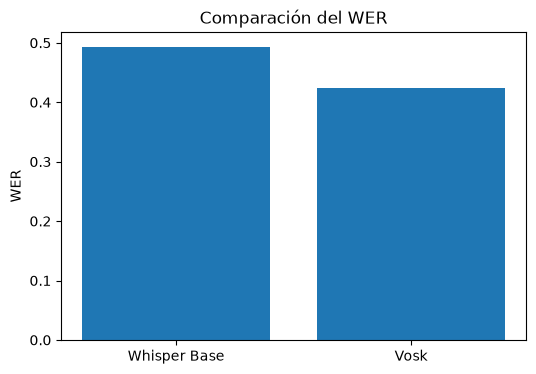

In [25]:
#Grafico de Wer
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(

    resumen["Modelo"],

    resumen["WER promedio"]

)

plt.title("Comparación del WER")

plt.ylabel("WER")

plt.show()

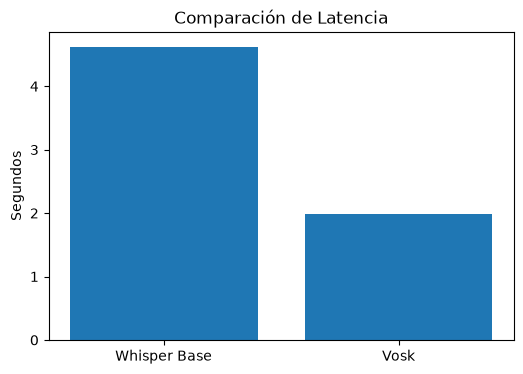

In [26]:
#Grafico de Latencia
plt.figure(figsize=(6,4))

plt.bar(

    resumen["Modelo"],

    resumen["Latencia promedio (s)"]

)

plt.title("Comparación de Latencia")

plt.ylabel("Segundos")

plt.show()

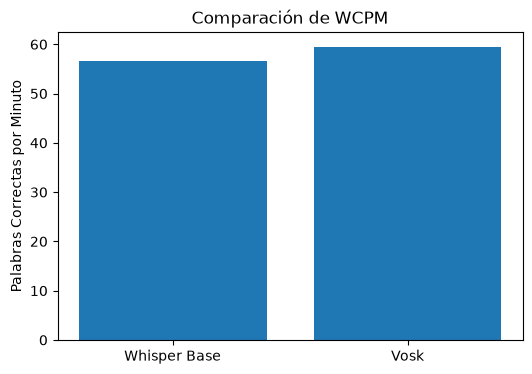

In [27]:
#Gráfico WCPM
plt.figure(figsize=(6,4))

plt.bar(

    resumen["Modelo"],

    resumen["WCPM promedio"]

)

plt.title("Comparación de WCPM")

plt.ylabel("Palabras Correctas por Minuto")

plt.show()

In [40]:
#Ecuación para ponderar los pesos de la métricas
PESO_WER = 0.50
PESO_LAT = 0.20
PESO_WCPM = 0.30

assert abs(PESO_WER + PESO_LAT + PESO_WCPM - 1) < 1e-6

In [37]:
WCPM_MAX = max(
    df["WCPM_Whisper"].max(),
    df["WCPM_Vosk"].max()
)

print(WCPM_MAX)

137.93103448275863


In [38]:
def calcular_ida(wer, latencia, wcpm, wcpm_max):

    score_wer = 1 - wer

    score_latencia = 1 / (1 + latencia)

    score_wcpm = wcpm / wcpm_max

    ida = (
        PESO_WER * score_wer
        + PESO_LAT * score_latencia
        + PESO_WCPM * score_wcpm
    )

    return ida

In [41]:
df["IDA_Whisper"] = df.apply(
    lambda x: calcular_ida(
        x["WER_Whisper"],
        x["Latencia_Whisper"],
        x["WCPM_Whisper"],
        WCPM_MAX
    ),
    axis=1
)

In [42]:
df["IDA_Vosk"] = df.apply(
    lambda x: calcular_ida(
        x["WER_Vosk"],
        x["Latencia_Vosk"],
        x["WCPM_Vosk"],
        WCPM_MAX
    ),
    axis=1
)

In [43]:
resumen_ida = pd.DataFrame({

    "Modelo": [
        "Whisper Base",
        "Vosk"
    ],

    "IDA Promedio": [
        df["IDA_Whisper"].mean(),
        df["IDA_Vosk"].mean()
    ]
})

resumen_ida

,Modelo,IDA Promedio
0,Whisper Base,0.424035
1,Vosk,0.493852


In [44]:
#Desciación Estandar
resumen_ida = pd.DataFrame({

    "Modelo": [
        "Whisper Base",
        "Vosk"
    ],

    "IDA Promedio": [
        df["IDA_Whisper"].mean(),
        df["IDA_Vosk"].mean()
    ],

    "Desv. Estándar": [
        df["IDA_Whisper"].std(),
        df["IDA_Vosk"].std()
    ]

})

resumen_ida

,Modelo,IDA Promedio,Desv. Estándar
0,Whisper Base,0.424035,0.269789
1,Vosk,0.493852,0.213921


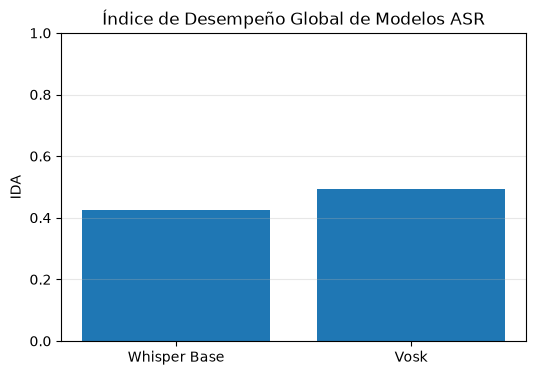

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    resumen_ida["Modelo"],
    resumen_ida["IDA Promedio"]
)

plt.ylabel("IDA")

plt.title("Índice de Desempeño Global de Modelos ASR")

plt.ylim(0,1)

plt.grid(axis="y", alpha=0.3)

plt.show()